# Wellington: despiking, spectra, and corrections
A complete field-data example using `data/output/Wellington_filtered.parquet`.
Run the cells in order. The default loads **27 June 2024, 12:00–13:00 in the
file's timestamp convention**, giving two 30-minute intervals. No timezone
conversion is assumed. Change the dates below to inspect other periods.

This file has gaps on an otherwise 10 Hz grid. We report coverage and reconstruct
only short gaps before spectral analysis; removing missing rows would distort the
frequency axis. The gap limits and instrument settings below are explicit example
assumptions. Confirm them against deployment metadata before using corrected fluxes.

Install with `pip install -e ".[notebooks]"` and open from the checkout or `examples/`.
The local Wellington file is required; no download is performed. Figures and tables
are written to `examples/outputs/wellington/` (rerunning replaces these outputs).

In [1]:
from pathlib import Path
from datetime import datetime, timedelta
from copy import deepcopy
import json
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/TaylorSwift").is_dir())
sys.path.insert(0, str(ROOT / "src"))
import TaylorSwift as tswift

OUTPUT = ROOT / "examples/outputs/wellington"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

def show_save(fig, name):
    fig.tight_layout()
    for suffix in ["png", "pdf"]:
        fig.savefig(OUTPUT / f"{name}.{suffix}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## 1. Adjustable inputs
The geographic coordinates below come from `data/wellington_cs.ini`. The height,
canopy, and IRGASON response/path settings are **illustrative assumptions**, not
verified Wellington deployment metadata. Temperature is assumed °C, pressure kPa,
CO₂ density mg/m³, water density g/m³, and wind m/s. Inspect the summary before
continuing. `T_SONIC` is used consistently; the separately named `T_SONIC_corr`
column is not substituted without knowing which corrections it already contains.

In [2]:
DATA_PATH = ROOT / "data/output/Wellington_filtered.parquet"
START = datetime(2024, 6, 27, 12)
END = datetime(2024, 6, 27, 13)  # exclusive; keep a whole number of 30-min blocks
SAMPLING_HZ = 10.0
AVERAGING_MINUTES = 30
MIN_ORIGINAL_COVERAGE = 0.85  # Explicit allowance for this file's ~10% missing grid slots.
MAX_GAP_SECONDS = 0.2        # Longer gaps stop the example; do not silently bridge them.
MISSING_SENTINELS = [-999.0, -9999.0]
CHANNELS = ["Ux", "Uy", "Uz", "T_SONIC", "CO2_density", "H2O_density"]

DESPIKE_ENABLED = True
DESPIKE_COLUMNS = CHANNELS
DESPIKE_OPTIONS = dict(prob_threshold=1e-6, max_iter=1, bulk_iqr=8.0)
COLUMN_OVERRIDES = {}  # Example: {"CO2_density": {"bulk_iqr": None}}
PLOT_INTERVAL = 0

site = tswift.SiteConfig(
    z_measurement=3.52, z_canopy=0.3,  # illustrative, verify at the station
    latitude=39.4453, longitude=-110.7288,
    sampling_freq=SAMPLING_HZ, averaging_period=AVERAGING_MINUTES,
)
instrument = tswift.InstrumentConfig(
    model="IRGASON", irga_type="open_path",
    sonic_path_length=0.10, irga_path_length=0.154,
    sensor_separation_lateral=0.0, sensor_separation_longitudinal=0.0,
    sensor_separation_vertical=0.0,
    tau_co2=0.1, tau_h2o=0.1, tau_T=0.0, tau_sonic_T=0.0,
)
APPLY_HIGH_FREQ = True
APPLY_LOW_FREQ = True
APPLY_WPL = True  # Density correction, separate from spectral corrections.

## 2. Read only the selected time range
Timestamp sorting, duplicate checks, and grid alignment checks protect the FFT
input. No complete 1 GB file is loaded into memory. Larger selections use more
memory; extend the time range gradually.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Place the Wellington Parquet file at {DATA_PATH}")
period = timedelta(minutes=AVERAGING_MINUTES)
step_us = round(1_000_000 / SAMPLING_HZ)
if END <= START or (END - START) % period:
    raise ValueError("Select a positive whole number of averaging intervals.")
if (START - START.replace(hour=0, minute=0, second=0, microsecond=0)) % period:
    raise ValueError("START must align with an averaging interval boundary.")
scan = pl.scan_parquet(DATA_PATH)
required = ["TIMESTAMP", *CHANNELS, "PA"]
missing = set(required) - set(scan.collect_schema().names())
if missing:
    raise ValueError(f"Missing required columns: {missing}")
raw = (scan.select(required)
       .filter((pl.col("TIMESTAMP") >= START) & (pl.col("TIMESTAMP") < END))
       .collect().sort("TIMESTAMP"))
if not len(raw) or raw["TIMESTAMP"].n_unique() != len(raw):
    raise ValueError("No rows, or duplicate timestamps; inspect the selected range.")
offsets = (raw["TIMESTAMP"].to_numpy().astype("datetime64[us]")
           - np.datetime64(START, "us")).astype("timedelta64[us]").astype(np.int64)
if np.any(offsets % step_us):
    raise ValueError("Timestamps are not aligned to the configured sample grid.")
raw = raw.with_columns([
    pl.when(pl.col(c).is_in(MISSING_SENTINELS) | ~pl.col(c).is_finite())
    .then(None).otherwise(pl.col(c)).cast(pl.Float64).alias(c)
    for c in [*CHANNELS, "PA"]
])
print(f"Loaded {len(raw):,} observations from {raw['TIMESTAMP'][0]} to {raw['TIMESTAMP'][-1]}")
display(raw.select([*CHANNELS, "PA"]).describe())
display(raw.select(pl.col("TIMESTAMP").diff().dt.total_microseconds()
                   .value_counts(sort=True).alias("Observed spacing (microseconds)")))

Loaded 32,400 observations from 2024-06-27 12:00:00.100000 to 2024-06-27 12:59:59.900000


statistic,Ux,Uy,Uz,T_SONIC,CO2_density,H2O_density,PA
str,f64,f64,f64,f64,f64,f64,f64
"""count""",32400.0,32400.0,32400.0,32400.0,32400.0,32400.0,32400.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",-1.846581,-0.061619,0.050949,27.60845,614.546068,12.209997,83.48104
"""std""",1.550317,1.346436,0.319594,0.960335,3.038943,0.452979,0.035736
"""min""",-7.149508,-3.621891,-2.208647,25.800959,560.019165,11.444914,83.407059
"""25%""",-2.880942,-1.036577,-0.156761,26.911016,613.270874,11.894557,83.449783
"""50%""",-1.956776,-0.161221,0.038145,27.495165,614.39679,12.10923,83.498611
"""75%""",-0.703327,0.875072,0.243182,28.140509,616.007141,12.425026,83.507309
"""max""",2.950536,5.037725,1.977149,32.868225,721.021729,16.097332,83.527519


Observed spacing (microseconds)
struct[2]
"{100000,28800}"
"{200000,3599}"
"{null,1}"


## 3. Restore the time grid with a bounded gap policy
Each interval is reindexed separately. A missing run may be filled only if its
length is at most `MAX_GAP_SECONDS` and original channel coverage exceeds the
configured minimum. Interior gaps use linear interpolation; a short boundary gap
uses the nearest observation. Coverage and filled counts are exported. These
reconstructed samples are separate from the subsequent spike replacements.

Regularly missing samples cannot be recovered exactly. Interpolation can attenuate
high-frequency variance, and the spectral corrections below do **not** undo that
loss. Do not treat the near-Nyquist tail as an independent validation of the sensor.

In [4]:
def longest_missing_run(mask):
    edges = np.diff(np.r_[False, mask, False].astype(int))
    starts, stops = np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)
    return int((stops - starts).max()) if len(starts) else 0

blocks, coverage_rows = [], []
t0 = START
while t0 < END:
    t1 = t0 + period
    observed = raw.filter((pl.col("TIMESTAMP") >= t0) & (pl.col("TIMESTAMP") < t1))
    grid = pl.DataFrame({"TIMESTAMP": pl.datetime_range(
        t0, t1, interval=f"{step_us}us", closed="left", eager=True)})
    block = grid.join(observed, on="TIMESTAMP", how="left")
    for col in [*CHANNELS, "PA"]:
        values = block[col].to_numpy()
        valid = np.isfinite(values)
        coverage = float(valid.mean())
        gap_seconds = longest_missing_run(~valid) / SAMPLING_HZ
        if coverage < MIN_ORIGINAL_COVERAGE or gap_seconds > MAX_GAP_SECONDS + 1e-9:
            raise ValueError(f"{t0} {col}: coverage={coverage:.1%}, longest gap={gap_seconds:.2f}s; "
                             "choose another interval or review the gap policy.")
        coverage_rows.append(dict(interval=t0, column=col, original_coverage=coverage,
                                  filled=int((~valid).sum()), longest_gap_seconds=gap_seconds))
        filled = np.interp(np.arange(len(values)), np.flatnonzero(valid), values[valid])
        block = block.with_columns(pl.Series(col, filled))
    blocks.append(block)
    t0 = t1
coverage_table = pl.DataFrame(coverage_rows)
regular = pl.concat(blocks)
display(coverage_table)

interval,column,original_coverage,filled,longest_gap_seconds
datetime[μs],str,f64,i64,f64
2024-06-27 12:00:00,"""Ux""",0.9,1800,0.1
2024-06-27 12:00:00,"""Uy""",0.9,1800,0.1
2024-06-27 12:00:00,"""Uz""",0.9,1800,0.1
2024-06-27 12:00:00,"""T_SONIC""",0.9,1800,0.1
2024-06-27 12:00:00,"""CO2_density""",0.9,1800,0.1
…,…,…,…,…
2024-06-27 12:30:00,"""Uz""",0.9,1800,0.1
2024-06-27 12:30:00,"""T_SONIC""",0.9,1800,0.1
2024-06-27 12:30:00,"""CO2_density""",0.9,1800,0.1


## 4. Despike each interval and inspect replacements
The default `polars_ukde_despike` backend uses one gentle pass here. Lower the
probability threshold or increase `bulk_iqr` to preserve more of the tails;
`bulk_iqr=None` fits all finite values. Only `DESPIKE_COLUMNS` are cleaned.
The original observations and reconstructed pre-despike data remain available.

interval,column,replaced,percent
datetime[μs],str,i64,f64
2024-06-27 12:00:00,"""Ux""",0,0.0
2024-06-27 12:00:00,"""Uy""",0,0.0
2024-06-27 12:00:00,"""Uz""",0,0.0
2024-06-27 12:00:00,"""T_SONIC""",0,0.0
2024-06-27 12:00:00,"""CO2_density""",66,0.366667
…,…,…,…
2024-06-27 12:30:00,"""Uy""",0,0.0
2024-06-27 12:30:00,"""Uz""",0,0.0
2024-06-27 12:30:00,"""T_SONIC""",0,0.0


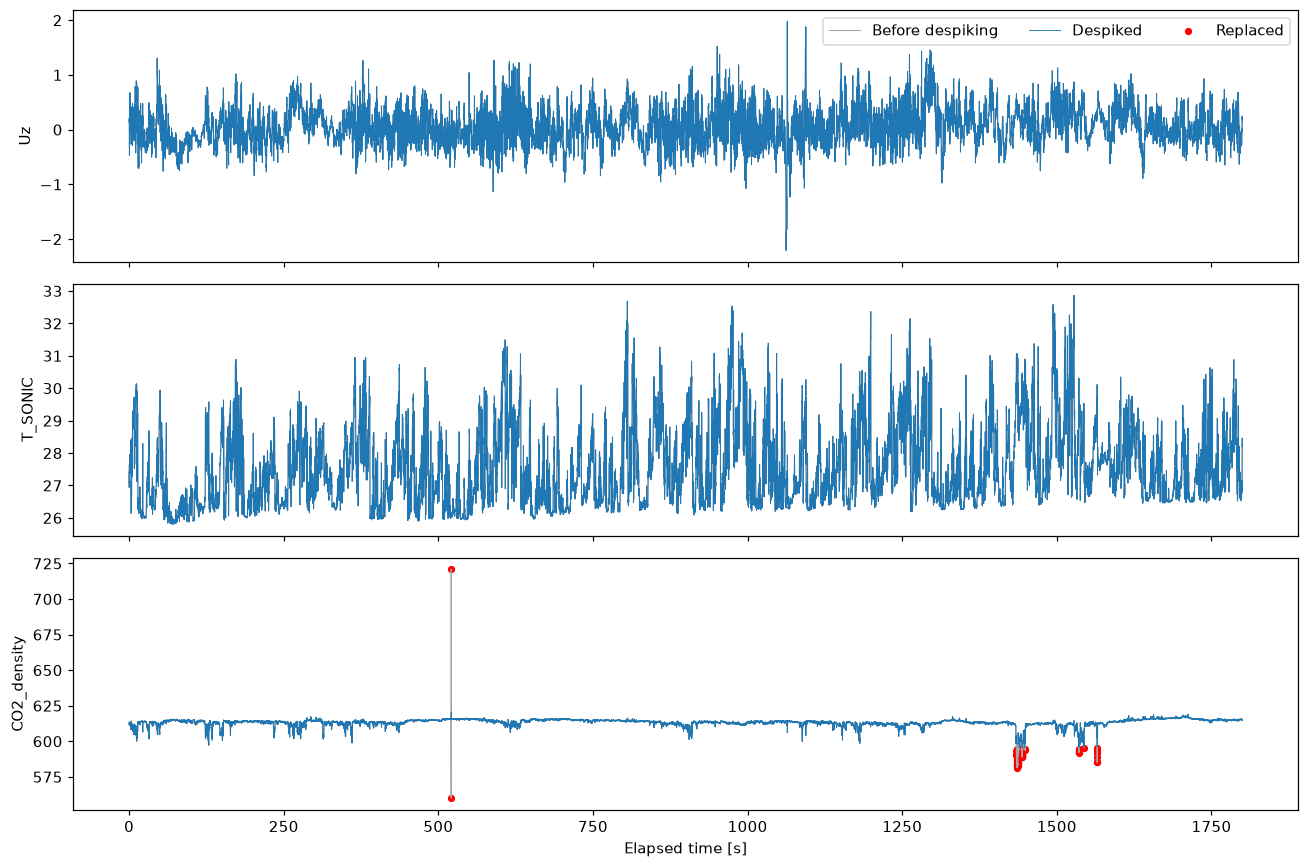

In [5]:
clean_blocks, changes = [], []
for block in blocks:
    clean = block
    for col in DESPIKE_COLUMNS:
        options = {**DESPIKE_OPTIONS, **COLUMN_OVERRIDES.get(col, {})}
        if not DESPIKE_ENABLED:
            options["max_iter"] = 0
        clean = tswift.despike_dataframe(clean, [col], **options)
    for col in CHANNELS:
        before, after = block[col].to_numpy(), clean[col].to_numpy()
        changed = np.isfinite(before) & (~np.isfinite(after) | (before != after))
        changes.append(dict(interval=block['TIMESTAMP'][0], column=col,
                            replaced=int(changed.sum()), percent=100 * float(changed.mean())))
    clean_blocks.append(clean)
clean = pl.concat(clean_blocks)
change_table = pl.DataFrame(changes)
display(change_table)

before, after = blocks[PLOT_INTERVAL], clean_blocks[PLOT_INTERVAL]
seconds = np.arange(len(before)) / SAMPLING_HZ
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, col in zip(axes, ["Uz", "T_SONIC", "CO2_density"]):
    a, b = before[col].to_numpy(), after[col].to_numpy()
    changed = np.isfinite(a) & (~np.isfinite(b) | (a != b))
    ax.plot(seconds, a, color="0.65", lw=0.7, label="Before despiking")
    ax.plot(seconds, b, lw=0.6, label="Despiked")
    ax.scatter(seconds[changed], a[changed], s=14, color="red", label="Replaced")
    ax.set_ylabel(col)
axes[0].legend(ncol=3)
axes[-1].set_xlabel("Elapsed time [s]")
show_save(fig, "01_despiking")

## 5. Spectral analysis and quality diagnostics
Compute both pre-despike and despiked results to see the effect of cleaning.
`process_file` rotates wind, detrends, windows, computes FFTs, and bins spectra.
`run_qc` annotates results; it does not automatically discard intervals.
Inspect the diagnostics before interpreting corrected fluxes.

timestamp_start,u_mean,ustar,zL,H,interval_status
datetime[μs],f64,f64,f64,f64,str
2024-06-27 12:00:00,1.692477,0.280157,-0.341351,207.97622,"""ok"""
2024-06-27 12:30:00,2.024686,0.248604,-0.204853,87.241401,"""ok"""


diagnostic,value
str,str
"""vm97_u_n_spikes""","""1"""
"""vm97_u_spike_frac""","""5.555555555555556e-05"""
"""vm97_u_skewness""","""0.12148010335034087"""
"""vm97_u_kurtosis""","""2.6332118902056734"""
"""vm97_u_ampres_flag""","""False"""
…,…
"""slope_class_w""","""acceptable"""
"""slope_T""","""-0.7008053964488735"""
"""slope_r2_T""","""0.9423054886701173"""


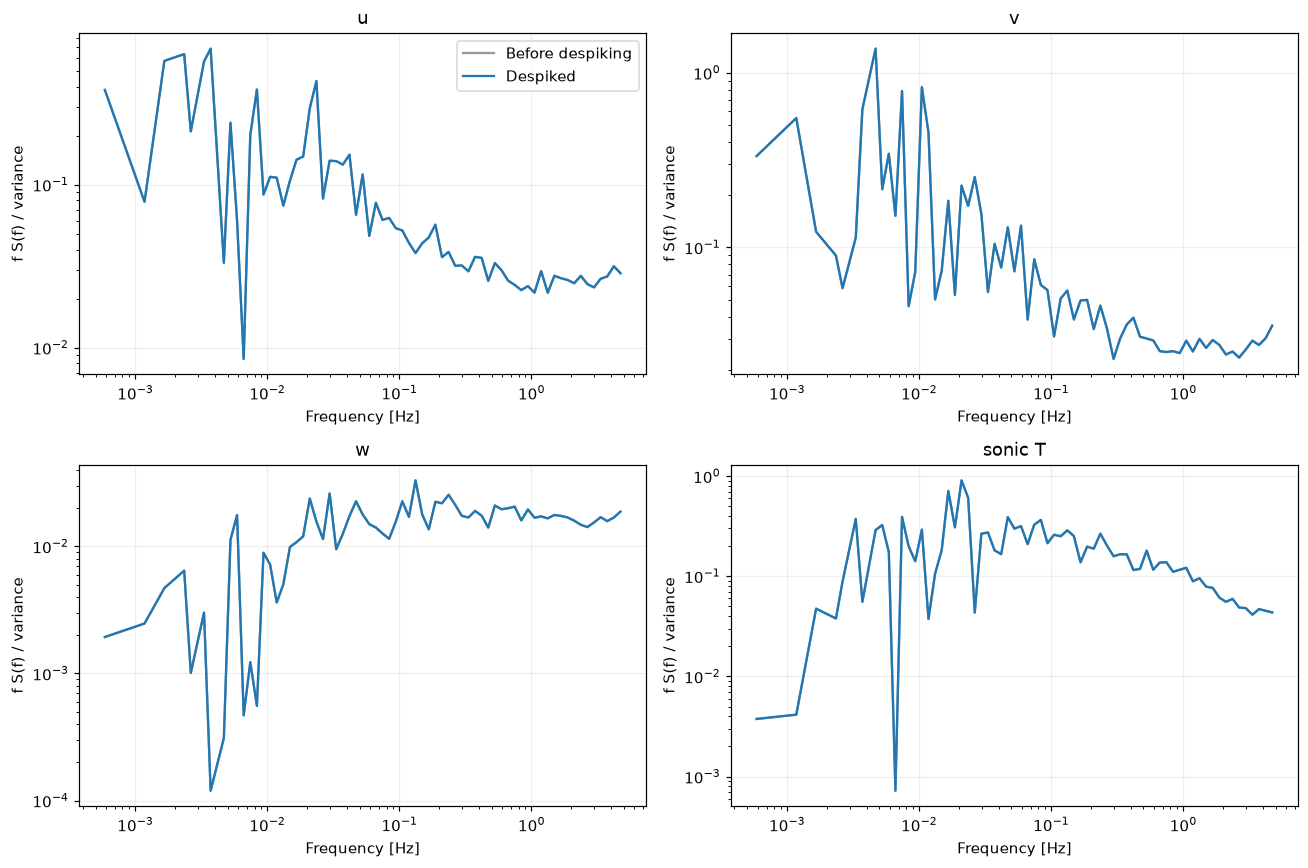

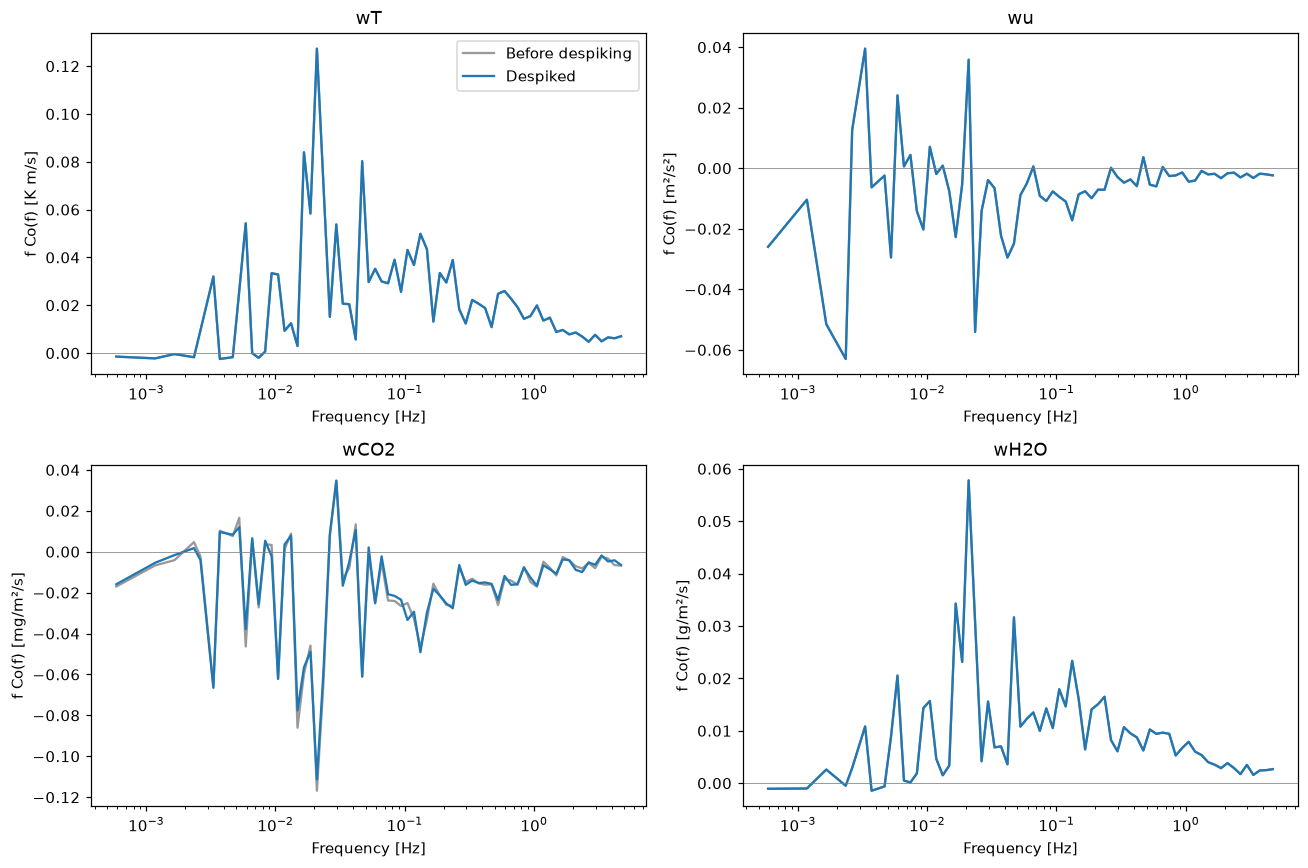

In [6]:
before_results = tswift.run_qc(tswift.process_file(regular, site))
results = tswift.run_qc(tswift.process_file(clean, site))
expected_intervals = len(blocks)
if len(results) != expected_intervals or len(before_results) != expected_intervals:
    raise ValueError("Some intervals were skipped; inspect coverage and sample frequency.")
if any(not len(r.freq) or not np.isfinite(r.freq).all() for r in results):
    raise ValueError("One or more intervals have no usable spectra; inspect channel quality.")
summary_before_corrections = tswift.results_to_dataframe(results)
display(summary_before_corrections.select(
    "timestamp_start", "u_mean", "ustar", "zL", "H", "interval_status"))
display(pl.DataFrame({"diagnostic": list(results[PLOT_INTERVAL].qc_flags),
                     "value": [str(v) for v in results[PLOT_INTERVAL].qc_flags.values()]}))

r0, r = before_results[PLOT_INTERVAL], results[PLOT_INTERVAL]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, field, label in zip(axes.flat,
        ["spec_u", "spec_v", "spec_w", "spec_T"], ["u", "v", "w", "sonic T"]):
    ax.loglog(r0.freq, getattr(r0, field), color="0.6", label="Before despiking")
    ax.loglog(r.freq, getattr(r, field), label="Despiked")
    ax.set(xlabel="Frequency [Hz]", ylabel="f S(f) / variance", title=label)
    ax.grid(alpha=0.2)
axes[0, 0].legend()
show_save(fig, "02_power_spectra")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, field, unit in zip(axes.flat, ["wT", "wu", "wCO2", "wH2O"],
        ["K m/s", "m²/s²", "mg/m²/s", "g/m²/s"]):
    ax.semilogx(r0.freq, getattr(r0, f"cosp_{field}"), color="0.6", label="Before despiking")
    ax.semilogx(r.freq, getattr(r, f"cosp_{field}"), label="Despiked")
    ax.axhline(0, color="0.5", lw=0.5)
    ax.set(xlabel="Frequency [Hz]", ylabel=f"f Co(f) [{unit}]", title=field)
axes[0, 0].legend()
show_save(fig, "03_signed_cospectra")

## 6. Apply spectral corrections, then density corrections
High-frequency correction accounts for the configured sensor response, path
averaging, and sensor separation. Low-frequency correction includes block
averaging; the current implementation does not correct linear detrending.
Massman model factors scale covariances, while frequency-by-frequency deconvolution
is exported as a separate estimator. These need not give identical integrals.

WPL is an additional open-path density correction, not a spectral correction.
Measured `PA` supplies pressure. This example only enables WPL for intervals with
finite positive measured pressure, avoiding a standard-atmosphere fallback.
Corrections remain conditional on the instrument assumptions above. The source
file's prior filtering history is unknown: avoid applying a physical correction
twice if that history indicates it has already been performed.

timestamp_start,cf_wT,cf_wu,cf_wCO2,cf_wH2O,H,H_corrected,spectral_status,wpl_status,wpl_pressure_source,wpl_Fc,wpl_Fe
datetime[μs],f64,f64,f64,f64,f64,f64,str,str,str,f64,f64
2024-06-27 12:00:00,1.038619,1.043867,1.076257,1.076257,207.97622,216.00807,"""applied""","""applied""","""measured""",0.317136,0.090686
2024-06-27 12:30:00,1.034797,1.041585,1.078696,1.078696,87.241401,90.277177,"""applied""","""applied""","""measured""",0.348948,0.052179


H: W/m²; wpl_Fc: mg CO₂/m²/s; wpl_Fe: g H₂O/m²/s


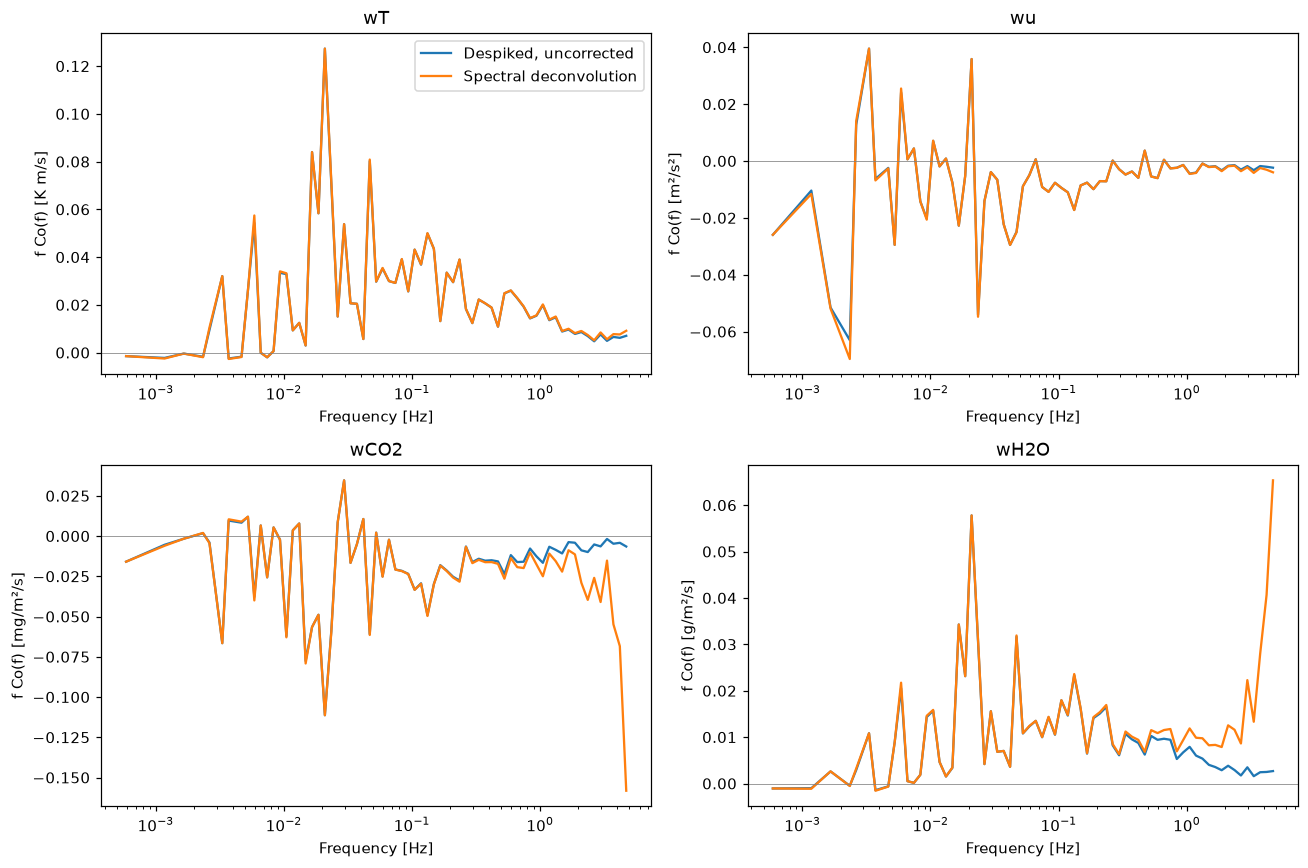

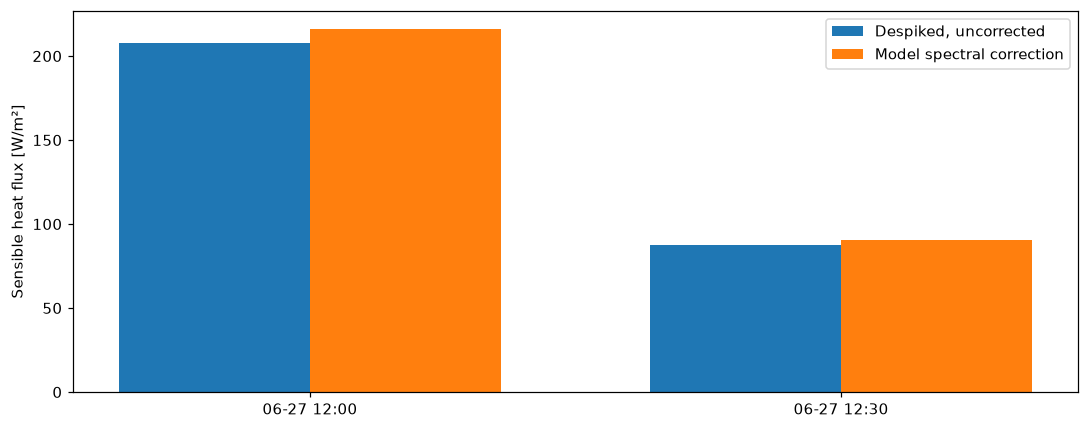

In [7]:
# Copy so rerunning this cell always starts from the uncorrected results.
corrected_results = deepcopy(results)
tswift.enrich_results_with_means(corrected_results, clean, site)
for item in corrected_results:
    measured_pressure_ok = item.P_mean is not None and np.isfinite(item.P_mean) and item.P_mean > 0
    tswift.apply_spectral_corrections(
        [item], site, instrument,
        apply_high_freq=APPLY_HIGH_FREQ, apply_low_freq=APPLY_LOW_FREQ,
        apply_wpl=APPLY_WPL and measured_pressure_ok, method="massman",
    )
    if APPLY_WPL and not measured_pressure_ok:
        item.qc_flags["wpl_status"] = "skipped_missing_measured_pressure"

corrected_table = tswift.results_to_dataframe(corrected_results)
report_columns = ["timestamp_start", "cf_wT", "cf_wu", "cf_wCO2", "cf_wH2O",
                  "H", "H_corrected", "spectral_status", "wpl_status",
                  "wpl_pressure_source", "wpl_Fc", "wpl_Fe"]
display(corrected_table.select([c for c in report_columns if c in corrected_table.columns]))
print("H: W/m²; wpl_Fc: mg CO₂/m²/s; wpl_Fe: g H₂O/m²/s")

r = corrected_results[PLOT_INTERVAL]
if not r.corrected_spectra:
    raise ValueError(f"No corrected spectra for selected interval: {r.qc_flags['spectral_status']}")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, field, unit in zip(axes.flat, ["wT", "wu", "wCO2", "wH2O"],
        ["K m/s", "m²/s²", "mg/m²/s", "g/m²/s"]):
    ax.semilogx(r.freq, getattr(r, f"cosp_{field}"), label="Despiked, uncorrected")
    ax.semilogx(r.freq, r.corrected_spectra[f"cosp_{field}"], label="Spectral deconvolution")
    ax.axhline(0, color="0.5", lw=0.5)
    ax.set(xlabel="Frequency [Hz]", ylabel=f"f Co(f) [{unit}]", title=field)
axes[0, 0].legend()
show_save(fig, "04_spectral_corrections")

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(corrected_results))
ax.bar(x - 0.18, [v.H for v in corrected_results], width=0.36, label="Despiked, uncorrected")
ax.bar(x + 0.18, [v.qc_flags['H_corrected'] for v in corrected_results],
       width=0.36, label="Model spectral correction")
ax.set_xticks(x, [v.timestamp_start.strftime("%m-%d %H:%M") for v in corrected_results])
ax.set_ylabel("Sensible heat flux [W/m²]")
ax.legend()
show_save(fig, "05_heat_flux_comparison")

## 7. Export results and settings
The scalar table retains raw covariances alongside model-corrected values and WPL
fluxes. A separate long table stores deconvolved cospectra and ogives; WPL does not
alter those arrays. Review correction statuses and factors, especially when wind
is weak or factors become large. No changes are made to the source Parquet file.

In the executed example, deconvolution visibly amplifies the gas-channel tails
near 5 Hz. Those bins are sensitive to response-time assumptions, noise, and
gap interpolation. Use the separately reported model factors for the model-scaled
flux comparison; do not interpret the amplified tail as recovered turbulence.

In [8]:
from dataclasses import asdict

coverage_table.write_csv(OUTPUT / "original_coverage.csv")
change_table.write_csv(OUTPUT / "despike_changes.csv")
corrected_table.write_csv(OUTPUT / "interval_results.csv")
corrected_table.write_parquet(OUTPUT / "interval_results.parquet")
tswift.spectra_to_dataframe(results).write_parquet(OUTPUT / "uncorrected_spectra.parquet")
arrays = []
for item in corrected_results:
    if item.corrected_spectra:
        arrays.append(pl.DataFrame({
            "timestamp_start": [item.timestamp_start] * len(item.freq),
            "frequency_hz": item.freq, **item.corrected_spectra,
        }))
if arrays:
    pl.concat(arrays).write_parquet(OUTPUT / "deconvolved_spectra.parquet")
settings = dict(data_path=str(DATA_PATH), start=START.isoformat(), end=END.isoformat(),
                package_version=tswift.__version__, site=asdict(site), instrument=asdict(instrument),
                minimum_original_coverage=MIN_ORIGINAL_COVERAGE, max_gap_seconds=MAX_GAP_SECONDS,
                missing_sentinels=MISSING_SENTINELS, despike_enabled=DESPIKE_ENABLED,
                despike_columns=DESPIKE_COLUMNS, despike_options=DESPIKE_OPTIONS,
                column_overrides=COLUMN_OVERRIDES, apply_high_freq=APPLY_HIGH_FREQ,
                apply_low_freq=APPLY_LOW_FREQ, apply_wpl=APPLY_WPL)
(OUTPUT / "settings.json").write_text(json.dumps(settings, indent=2), encoding="utf-8")
print(f"Saved plots, diagnostic tables, spectra, and settings to {OUTPUT}")

Saved plots, diagnostic tables, spectra, and settings to C:\Users\paulinkenbrandt\Documents\Github\TaylorSwift\examples\outputs\wellington
